In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preproccessing


In [4]:
### Handling Missing Vlue 

df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [6]:
#Age
df["Age"] = 2026 - df["Year_Birth"]


In [7]:
#Customer tenure

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days'],
      dtype='object')

In [9]:
# total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [11]:
#Children
df["TotalChild"] = df["Kidhome"] + df["Teenhome"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,TotalChild
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [12]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate", "Master":"Postgraduate"
})

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,TotalChild
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
df["Marital_Status"].value_counts()
df["Living_with"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner",
    "Single":"Alone", "Divorced":"Alone", "Widow":"Alone", "Absurd":"Alone", "YOLO":"Alone"
})

## Drop Columns


In [14]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome","Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols+spending_cols  
df_cleaned = df.drop(columns = cols_to_drop)


In [15]:
df_cleaned.shape

(2240, 15)

# Outliers

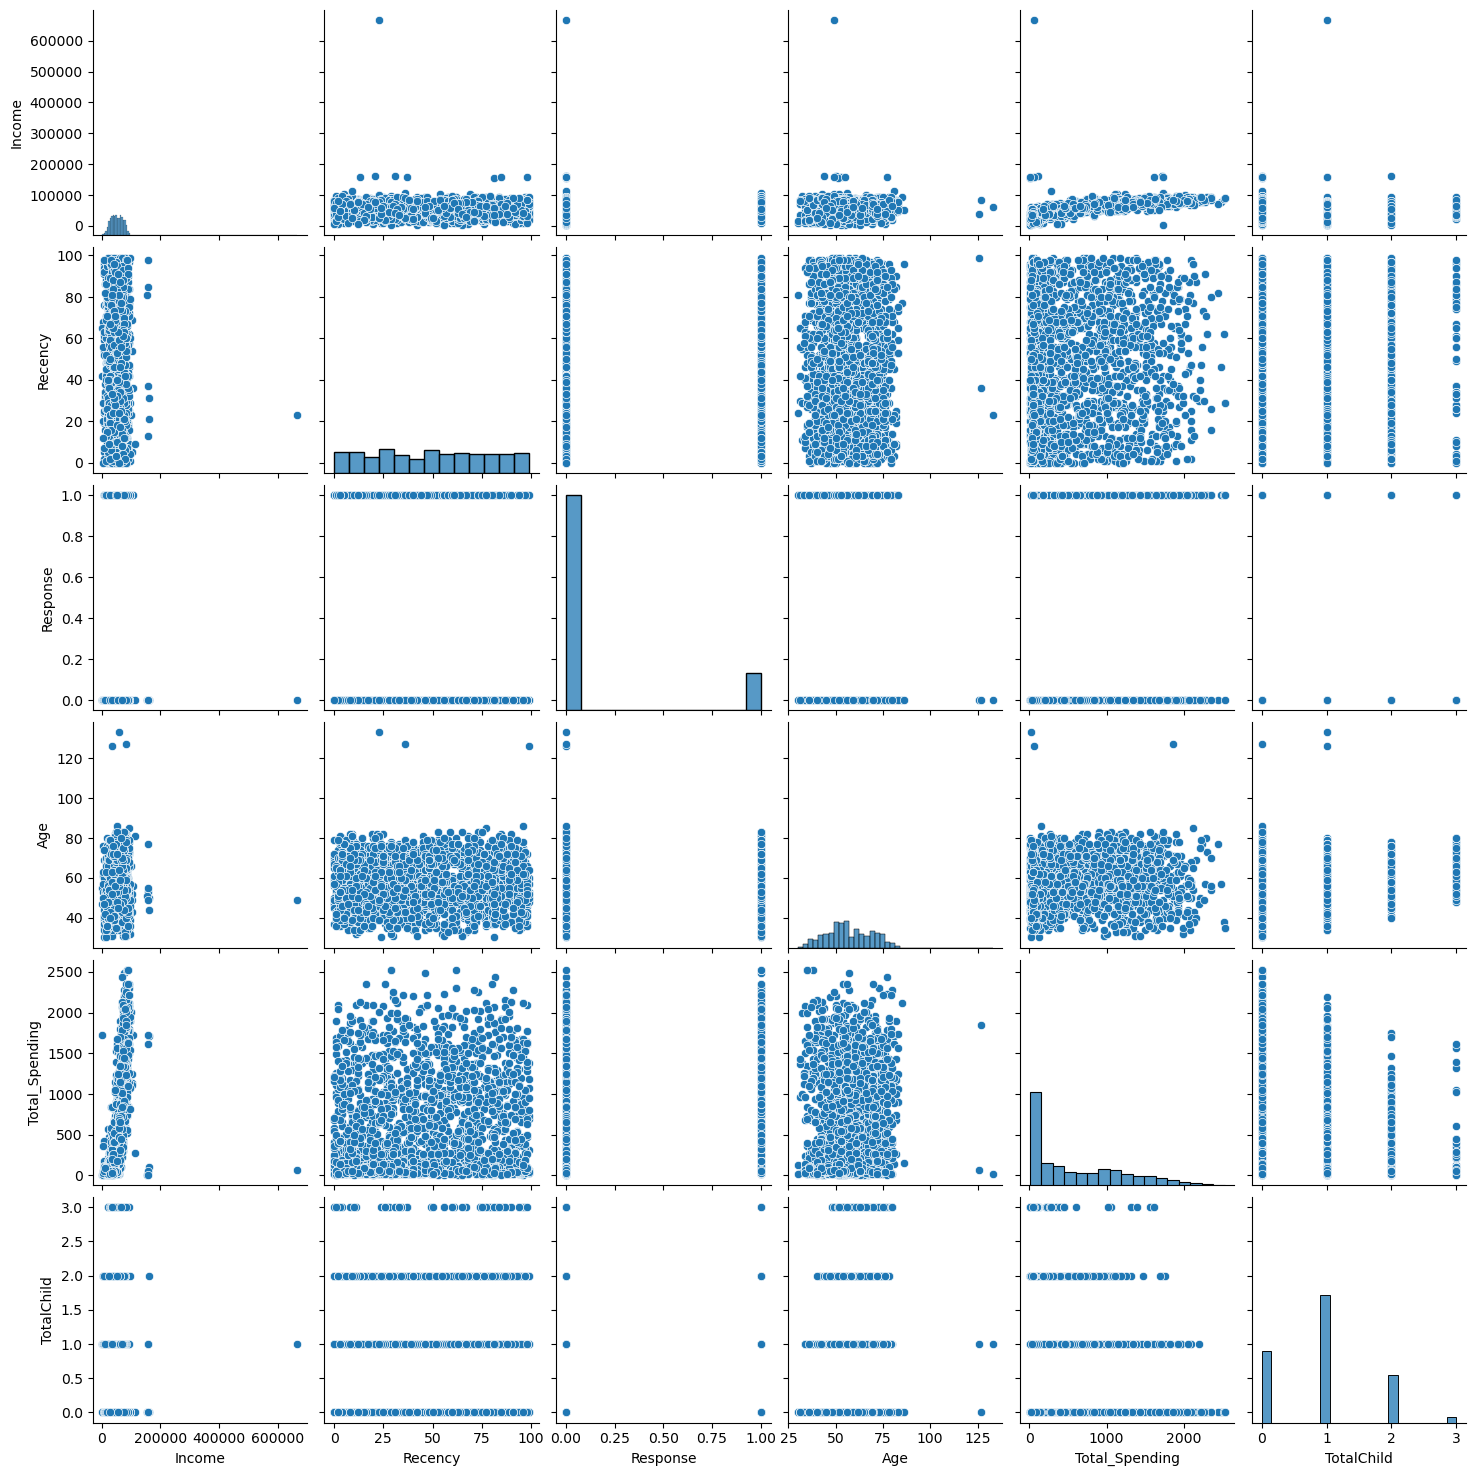

In [16]:
# Pairplots 
import seaborn as sns
num_cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "TotalChild"]

sns.pairplot(df_cleaned[num_cols])


### As per the above pair plot diagram we can see two outliers present in the data set. 
### 1. Income greter than 600000
### 2. Age is above 90

In [17]:
# Removing Outliers
print("Data size with outlers: ", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600000)]
print("Data size without outlers: ", len(df_cleaned))

Data size with outlers:  2240
Data size without outlers:  2236


In [18]:
# Heat map

corr = df_cleaned.corr(numeric_only=True)

<Axes: >

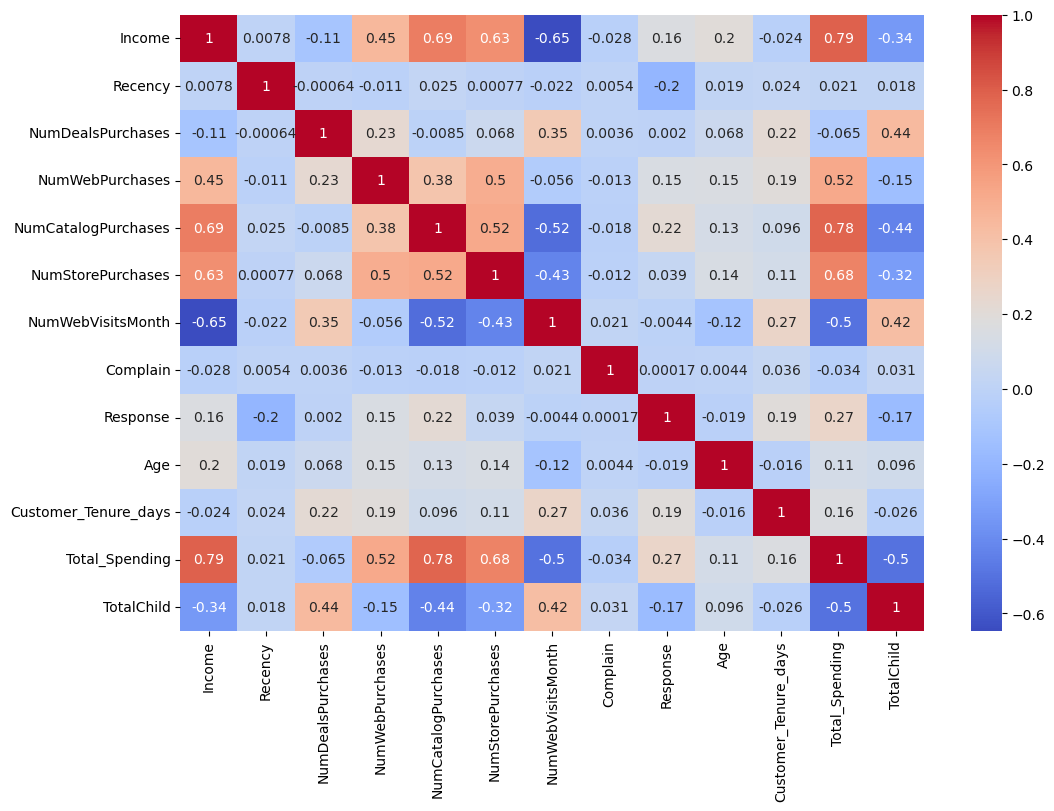

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=[12,8])
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)

## Key Insights from Correlation Heatmap (Loan Approval System)

### 1. Income is a strong indicator of spending behavior
- `Income` has a strong positive correlation with `Total_Spending` (**0.79**).
- Higher-income customers tend to spend more and purchase more products.
- This can be useful in loan approval because higher income generally indicates stronger repayment capac
---
### 2. Purchase activities increase with income
- `Income` and `NumCatalogPurchases` → **0.69**
- `Income` and `NumStorePurchases` → **0.63**
- `Income` and `NumWebPurchases` → **0.45**

Customers with higher income show stronger purchasing patterns.

---

### 3. Website visits alone may not indicate purchasing intent
- `NumWebVisitsMonth` has negative correlation with:
  - `Income` → **-0.65**
  - `Total_Spending` → **-0.50**
  - `NumCatalogPurchases` → **-0.52**
  - `NumStorePurchases` → **-0.43**


---

### 4. Total spending strongly depends on purchasing channels
Strong correlations with Total Spending:

- `NumCatalogPurchases` → **0.78**
- `NumStorePurchases` → **0.68**
- `NumWebPurchases` → **0.52**

---

### 5. Customers with more children tend to spend less
`TotalChild` shows:

- Negative correlation with `Total_Spending` → **-0.50**
- Negative correlation with `NumCatalogPurchases` → **-0.44**
- Negative correlation with `NumStorePurchases` → **-0.32**

---

### 6. Customer tenure has weak relationship with most variables
`Customer_Tenure_days` has very low correlations across most features.

---

### 7. Complaint behavior has minimal impact
`Complain` has correlations close to **0** with most variables.

---

### 8. Response variable has weak relationships
`Response` shows weak correlations with all features.

---

### 9. Potential multicollinearity exists
Strong correlations observed:

- `Income ↔ Total_Spending` (**0.79**)
- `NumCatalogPurchases ↔ Total_Spending` (**0.78**)
- `NumStorePurchases ↔ Total_Spending` (**0.68**)

**Business implication:**  
Before model building, perform:
- VIF (Variance Inflation Factor)
- Feature selection
- Regularization techniques

to avoid multicollinearity issues.

---

## Final Recommendation for Loan Approval Feature Engineering

High priority features:

- Income
- Total Spending
- Number of Purchases
- Customer Purchase Channels
- Family Size (TotalChild)

Lower priority features:

- Complaint
- Recency
- Customer Tenure
- Response

These insights can guide feature selection and improve prediction accuracy in the loan approval model.

In [20]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,TotalChild,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [23]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [25]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [26]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,TotalChild,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

In [30]:
X = df_encoded

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
X_scaled.shape

(2236, 18)

# Visualization

In [39]:
# 3D

from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D Projection')

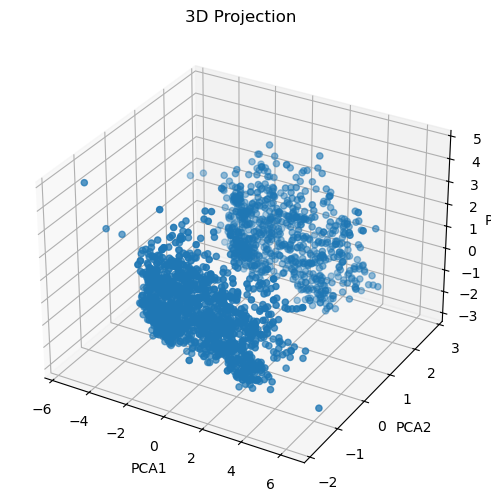

In [46]:
#plot
fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [41]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analysing K-Value

In [47]:
#Elbow Method

from sklearn.cluster import KMeans
from kneed import KneeLocator

In [51]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state =42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [52]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction="decreasing")
optimal_k = knee.elbow

print("The best K value =", optimal_k)

The best K value = 4


Text(0, 0.5, 'wcss')

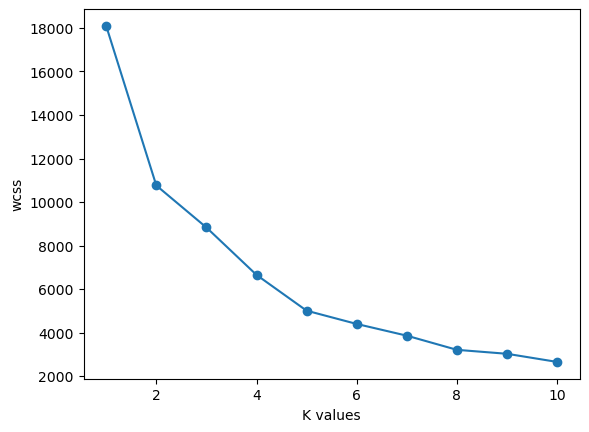

In [53]:
#plot

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K values")
plt.ylabel("wcss")

Text(0, 0.5, 'Scores')

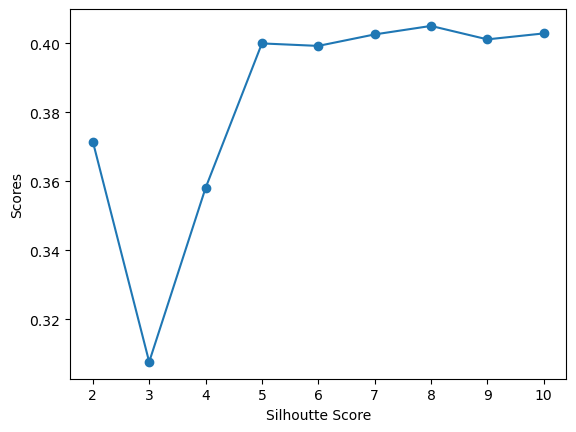

In [58]:
#silhoutte
from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Silhoutte Score")
plt.ylabel("Scores")

Text(0, 0.5, 'SS')

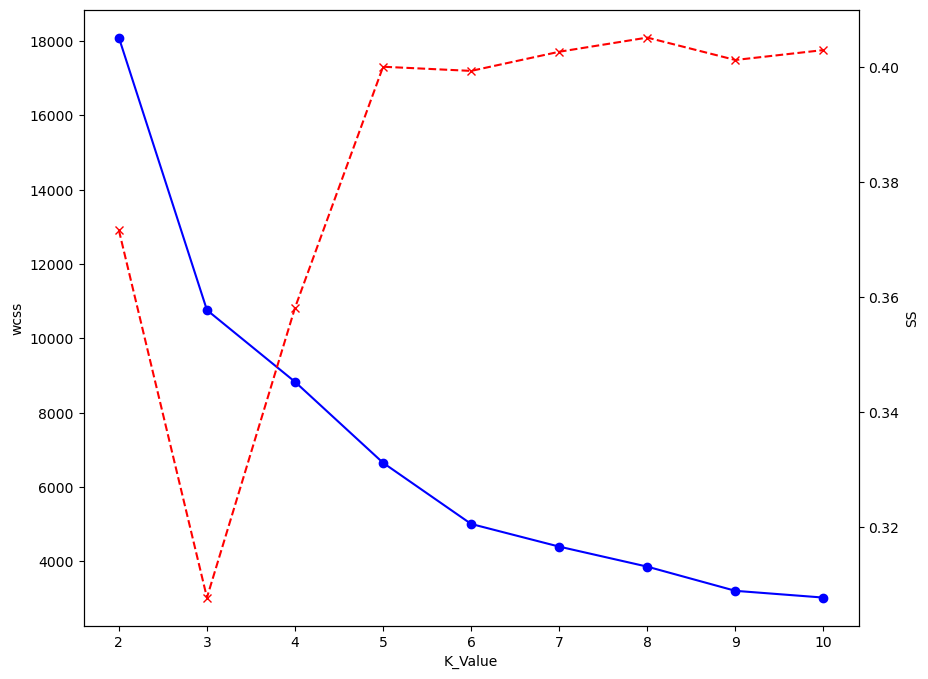

In [66]:
#combined plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(10,8))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color = "blue")
ax1.set_xlabel("K_Value")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker='x', color = "red", linestyle = "--")
ax2.set_ylabel("SS")

Text(0.5, 0.92, '3D Projection')

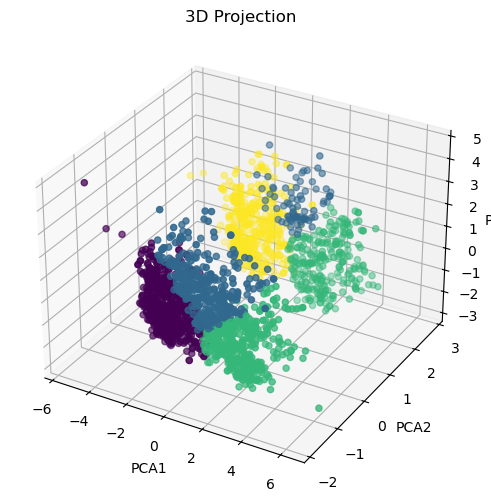

In [67]:
# Clustering Algorithm
kmeans = KMeans(n_clusters = 4, random_state=42)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

# AgglomerativeClustering

Text(0.5, 0.92, '3D Projection')

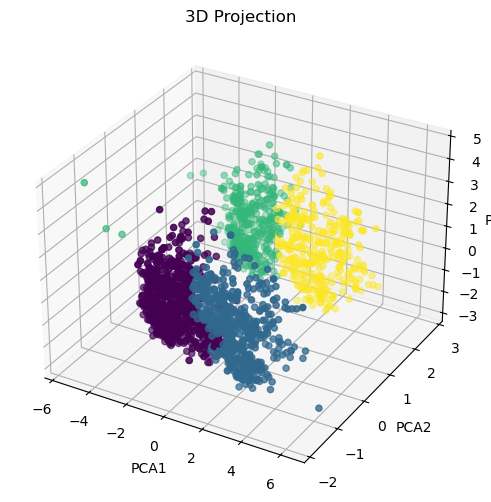

In [70]:
from sklearn.cluster import AgglomerativeClustering

AC = AgglomerativeClustering(n_clusters=4, linkage='ward')
lebels_agg = AC.fit_predict(X_pca)

fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=lebels_agg)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [75]:
X["cluster"] = lebels_agg


<bound method Series.drop of 0       3
1       2
2       1
3       0
4       0
       ..
2235    0
2236    0
2237    3
2238    1
2239    0
Name: labels, Length: 2236, dtype: int64>

In [82]:
X = X.drop("labels", axis=1)
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,TotalChild,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

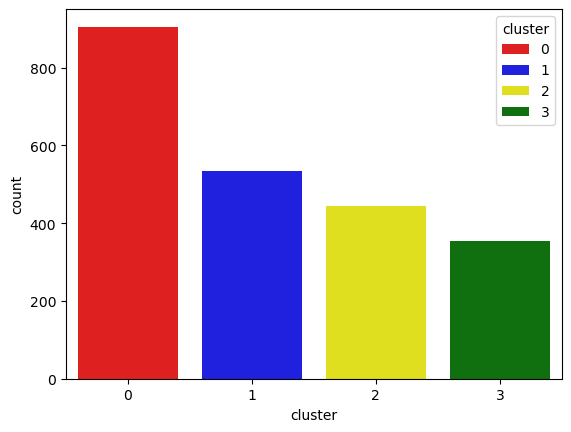

In [83]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

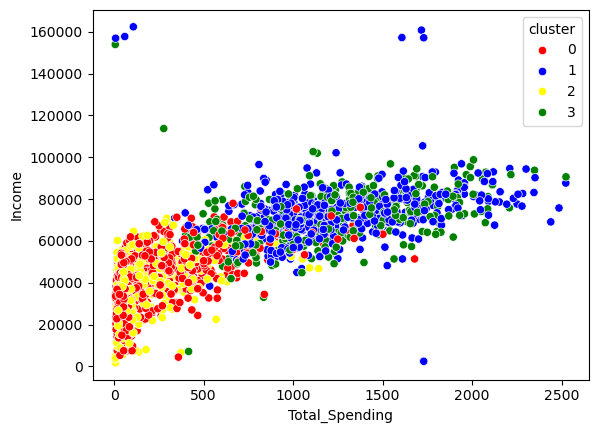

In [84]:
sns.scatterplot(x=X["Total_Spending"], y = X["Income"], hue=X["cluster"], palette = pal)

In [85]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_days  Total_Spending  \
cluster         